# 모델 적용
- 수식을 통해 직접 적용, 라이브러리 사용

In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

iris = load_iris(as_frame=True)
data = iris.data
X = data.drop(columns=['petal width (cm)'])
y = data['petal width (cm)'].to_numpy()
X.shape, y.shape

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

- 머신러닝
- 딥러닝
- 평가지표를 다양하게

In [16]:
# 머신러닝
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
xgb = XGBRegressor()
xgb.fit(X_train,y_train)
r2_score(y_test, xgb.predict(X_test))

0.9150999096630922

In [18]:
# 딥러닝
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
torch.manual_seed(42)

X_train_t = torch.FloatTensor(X_train)
X_test_t = torch.FloatTensor(X_test)
y_train_t = torch.FloatTensor(y_train)
y_test_t = torch.FloatTensor(y_test)
train_dataset = TensorDataset(X_train_t,y_train_t)
test_dataset = TensorDataset(X_test_t,y_test_t)
train_loader = DataLoader(train_dataset,batch_size=36,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32)

In [22]:
# 모델 정의
class IrisReg(nn.Module):
    def __init__(self, input_dim, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.network = nn.Sequential(            
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1)            
        )
    def forward(self,x):
        return self.network(x)

In [23]:
# 모델 학습
model = IrisReg(X_train.shape[1])
criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=0.001)
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch).squeeze()
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
model.eval()
with torch.no_grad():
    y_pred = model(X_test_t).squeeze().numpy()  
r2_score(y_test, y_pred)


0.8584891915131672

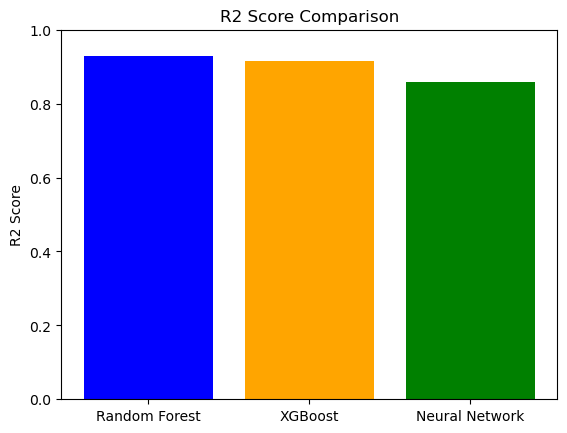

In [24]:
# 머신러닝 모델과 딥러닝 모델의 성능 비교 시각화
import matplotlib.pyplot as plt
models = ['Random Forest', 'XGBoost', 'Neural Network']
r2_scores = [r2_score(y_test, RandomForestRegressor().fit(X_train,y_train).predict(X_test)),
             r2_score(y_test, xgb.predict(X_test)),
             r2_score(y_test, y_pred)]
plt.bar(models, r2_scores, color=['blue', 'orange', 'green'])
plt.ylim(0, 1)
plt.title('R2 Score Comparison')
plt.ylabel('R2 Score')
plt.show()
